In [2]:
# IDEA DOWNSAMPLE TCD DATASET & train a model / fine-tune another model like UNet for quicker inference
# https://huggingface.co/datasets/restor/tcd

In [3]:
from datasets import load_dataset, Dataset

/home/ubuntu/work/saved_data/geoai-project/geoai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
ds = load_dataset(
    "restor/tcd",
    cache_dir="./data/tcd"
)
train_data = ds["train"]
test_data = ds["test"]

In [5]:
test_data

Dataset({
    features: ['image_id', 'image', 'height', 'width', 'annotation', 'oam_id', 'license', 'biome', 'crs', 'bounds', 'validation_fold', 'biome_name', 'lat', 'lon', 'segments', 'meta', 'coco_annotations'],
    num_rows: 439
})

In [6]:
from PIL import Image

def downsample_to_5m_simple(example, target_gsd=5.0):
    # Extract original GSD from bounds and dimensions
    bounds = example["bounds"]          # [minx, miny, maxx, maxy]
    w, h = example["width"], example["height"]
    gsd_x = (bounds[2] - bounds[0]) / w
    gsd_y = (bounds[3] - bounds[1]) / h

    # Compute new size
    new_w = int(round(w * gsd_x / target_gsd))
    new_h = int(round(h * gsd_y / target_gsd))

    # Ensure size is at least 1x1
    new_w = max(1, new_w)
    new_h = max(1, new_h)

    image = example["image"]
    mask = example["annotation"]
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    if not isinstance(mask, Image.Image):
        mask = Image.fromarray(mask)

    image_resized = image.resize((new_w, new_h), Image.BILINEAR)
    mask_resized = mask.resize((new_w, new_h), Image.NEAREST)

    example["image"] = image_resized
    example["annotation"] = mask_resized
    example["height"], example["width"] = new_h, new_w
    return example

In [7]:
# train_5m = ds["train"].map(downsample_to_5m_simple)
# test_5m  = ds["test"].map(downsample_to_5m_simple)
train_5m = Dataset.load_from_disk("./data/tcd_5m_train")
test_5m  = Dataset.load_from_disk("./data/tcd_5m_test")

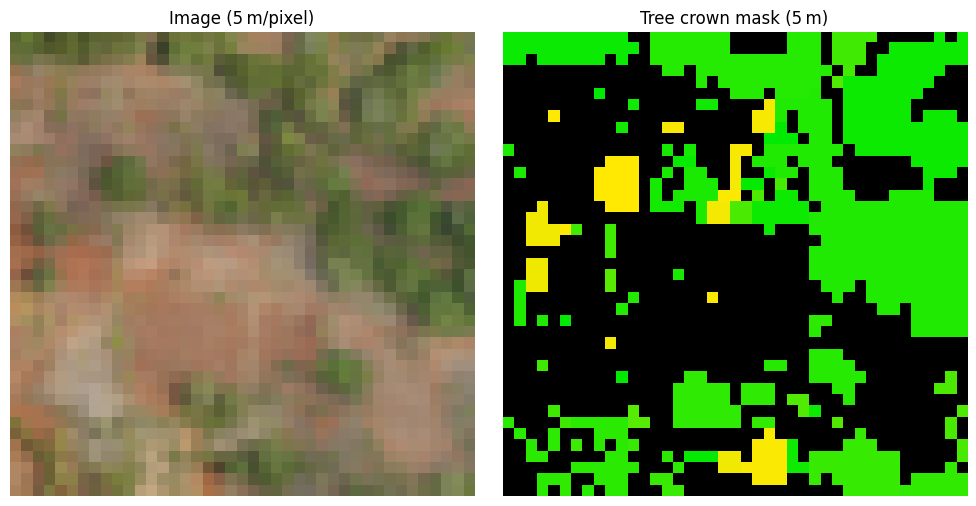

In [8]:
import numpy as np
import matplotlib.pyplot as plt

sample = test_5m[11]
img = np.array(sample["image"])        # (H, W, 3) RGB
mask = np.array(sample["annotation"])  # (H, W) class labels

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title("Image (5 m/pixel)")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray", interpolation="nearest")
axes[1].set_title("Tree crown mask (5 m)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [9]:
# train_5m.save_to_disk("./data/tcd_5m_train")
# test_5m.save_to_disk("./data/tcd_5m_test")

In [10]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image

class TreeDataset(Dataset):
    def __init__(self, hf_dataset, target_size=(64, 64)):
        self.ds = hf_dataset
        self.target_size = target_size  # (height, width)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]

        # --- Image: force RGB ---
        img = sample["image"]
        if isinstance(img, Image.Image):
            img = img.convert("RGB")   # ensures 3 channels

        # ---(single channel) ---
        mask = sample["annotation"]
        if isinstance(mask, Image.Image):
            mask = mask.convert("L")   # grayscale
        else:
            mask = Image.fromarray(mask).convert("L")

        # Resize
        img_resized = img.resize(self.target_size, Image.BICUBIC)
        mask_resized = mask.resize(self.target_size, Image.NEAREST)

        # Convert to numpy
        img_np = np.array(img_resized).transpose(2, 0, 1).astype(np.float32) / 255.0
        mask_np = np.array(mask_resized)

        # Ensure mask is binary (0/1)
        mask_np = (mask_np > 0).astype(np.float32)

        # Convert to tensors
        img_tensor = torch.from_numpy(img_np)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0)  # (1, H, W)

        return img_tensor, mask_tensor

In [11]:
batch_size = 128
target_dims = (64,64)
from torch.utils.data import DataLoader
train_loader = DataLoader(
    TreeDataset(train_5m,target_dims),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

test_loader = DataLoader(
    TreeDataset(test_5m, target_dims),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [12]:
for images, masks in train_loader:
    print(images.shape, masks.shape)  # Should be [16, 3, H, W] and [16, 1, H, W]
    break

torch.Size([128, 3, 64, 64]) torch.Size([128, 1, 64, 64])


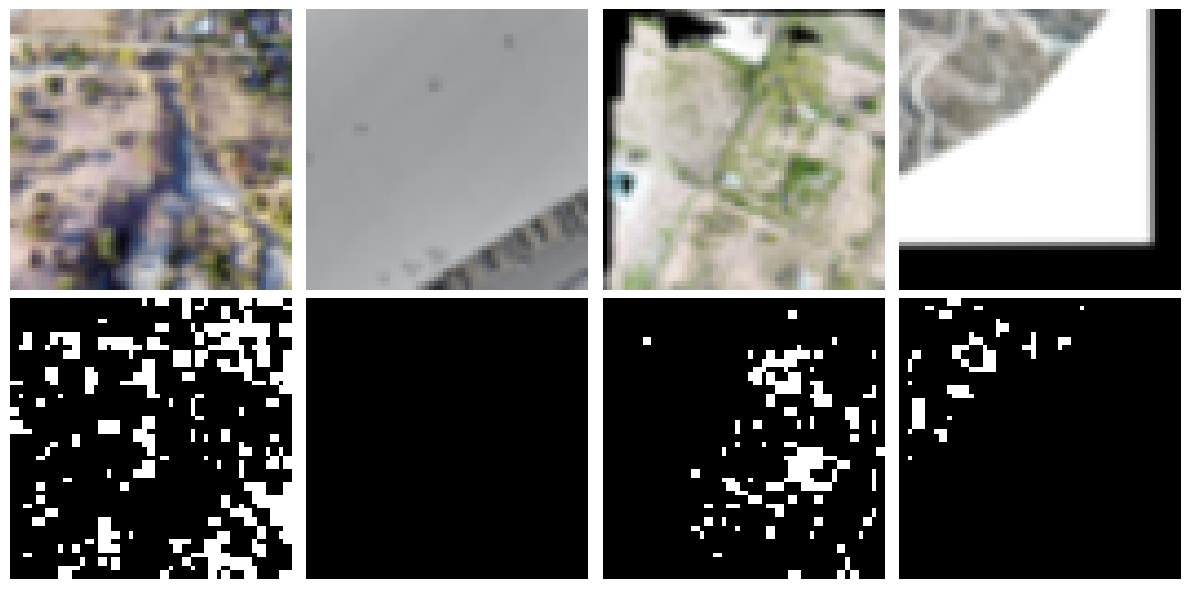

In [13]:
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    # Image
    img = images[i].permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    # Mask
    mask = masks[i].squeeze().numpy()
    axes[1, i].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [14]:
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet50",         
    encoder_weights="imagenet",    # Pre-trained on ImageNet
    in_channels=3,                    
    classes=1,
    activation=None, 
)

model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [15]:
import torch.nn as nn

dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()
tversky_loss = smp.losses.TverskyLoss(mode='binary', alpha=0.3, beta=0.7)

def combined_loss(pred, target):
    # return dice_loss(pred, target) +0.5 * tversky_loss(pred, target)
    return tversky_loss(pred,target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

In [16]:
def calculate_metrics(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred) > threshold
    pred = pred.float()
    target = target.float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
    
    return iou.item(), dice.item()

In [17]:
from tqdm import tqdm
import time

num_epochs = 50
best_val_iou = 0.0

# Store history for plotting
history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}

for epoch in range(1, num_epochs + 1):
    #   Training Phase  
    model.train()
    train_loss = 0.0
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    
    for images, masks in train_loader_tqdm:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward
        logits = model(images)
        loss = combined_loss(logits, masks)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_loader_tqdm.set_postfix(loss=loss.item())
    
    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)
    
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_dice = 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            images = images.to(device)
            masks = masks.to(device)
            
            logits = model(images)
            loss = combined_loss(logits, masks)
            val_loss += loss.item()
            
            # Metrics
            iou, dice = calculate_metrics(logits, masks)
            val_iou += iou
            val_dice += dice
    
    val_loss /= len(test_loader)
    val_iou /= len(test_loader)
    val_dice /= len(test_loader)
    
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)
    
    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val IoU = {val_iou:.4f}, Val Dice = {val_dice:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), "best_unet_tree_seg.pth")
        print(f"New best model saved with IoU = {val_iou:.4f}")

Epoch 1/50 [Val]: 100%|██████████| 4/4 [00:00<00:00, 11.27it/s]


Epoch 1: Train Loss = 0.4587, Val Loss = 0.4230, Val IoU = 0.4419, Val Dice = 0.6129
New best model saved with IoU = 0.4419


Epoch 2/50 [Val]: 100%|██████████| 4/4 [00:00<00:00, 12.01it/s]


Epoch 2: Train Loss = 0.3273, Val Loss = 0.3381, Val IoU = 0.4756, Val Dice = 0.6443
New best model saved with IoU = 0.4756


Epoch 3/50 [Val]: 100%|██████████| 4/4 [00:00<00:00, 12.44it/s]


...

Epoch 48: Train Loss = 0.1008, Val Loss = 0.2400, Val IoU = 0.5817, Val Dice = 0.7353


Epoch 49/50 [Val]: 100%|██████████| 4/4 [00:00<00:00, 12.26it/s]


Epoch 49: Train Loss = 0.1007, Val Loss = 0.2373, Val IoU = 0.5813, Val Dice = 0.7350


Epoch 50/50 [Val]: 100%|██████████| 4/4 [00:00<00:00, 12.83it/s]

Epoch 50: Train Loss = 0.0998, Val Loss = 0.2418, Val IoU = 0.5813, Val Dice = 0.7350


In [18]:
import rasterio
from rasterio.windows import Window

In [19]:
def plot_prediction(image_path: str, mask: np.ndarray, figsize=(15, 5)):
    alpha = 0.1
    with rasterio.open(image_path) as src:
        img = src.read([1, 2, 3])          # (3, H, W)
        img = np.moveaxis(img, 0, -1)      # (H, W, 3)
        if img.dtype != np.uint8:
            img = (img / img.max() * 255).astype(np.uint8)
    
    if mask.shape[:2] != img.shape[:2]:
        from PIL import Image
        mask_pil = Image.fromarray(mask * 255)
        mask_resized = mask_pil.resize((img.shape[1], img.shape[0]), Image.NEAREST)
        mask = (np.array(mask_resized) / 255).astype(np.uint8)
    
    overlay = np.zeros_like(img, dtype=np.uint8)
    overlay[:, :, 1] = 255  # green channel
    
    blended = img.copy().astype(np.float32)
    tree_pixels = mask == 1
    blended[tree_pixels] = (1 - alpha) * blended[tree_pixels] + alpha * overlay[tree_pixels]
    blended = blended.astype(np.uint8)
    
    # Plot
    plt.figure(figsize=figsize)
    plt.imshow(blended)
    plt.title("Satellite Image with Tree Mask Overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [20]:
def predict_small_image(
    image_path: str,
    model,
    device,
    target_size: tuple = (64, 64),
    threshold: float = 0.5,
) -> np.ndarray:
    with rasterio.open(image_path) as src:
        img = src.read([1, 2, 3])          # (3, H, W)
        img = np.moveaxis(img, 0, -1)      # (H, W, 3)
        orig_h, orig_w = img.shape[:2]
        print(orig_h, orig_w)

    img_pil = Image.fromarray(img).resize(target_size, Image.BICUBIC)
    img_np = np.array(img_pil).transpose(2, 0, 1).astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_np).unsqueeze(0).to(device)

    with torch.inference_mode():
        logits = model(img_tensor)
        prob = torch.sigmoid(logits).cpu().numpy().squeeze()  # (target_h, target_w)

    # Resize probability back to original image size
    prob_pil = Image.fromarray((prob * 255).astype(np.uint8))
    prob_resized = prob_pil.resize((orig_w, orig_h), Image.NEAREST)
    mask = (np.array(prob_resized) / 255.0) > threshold
    return mask.astype(np.uint8)

170 488


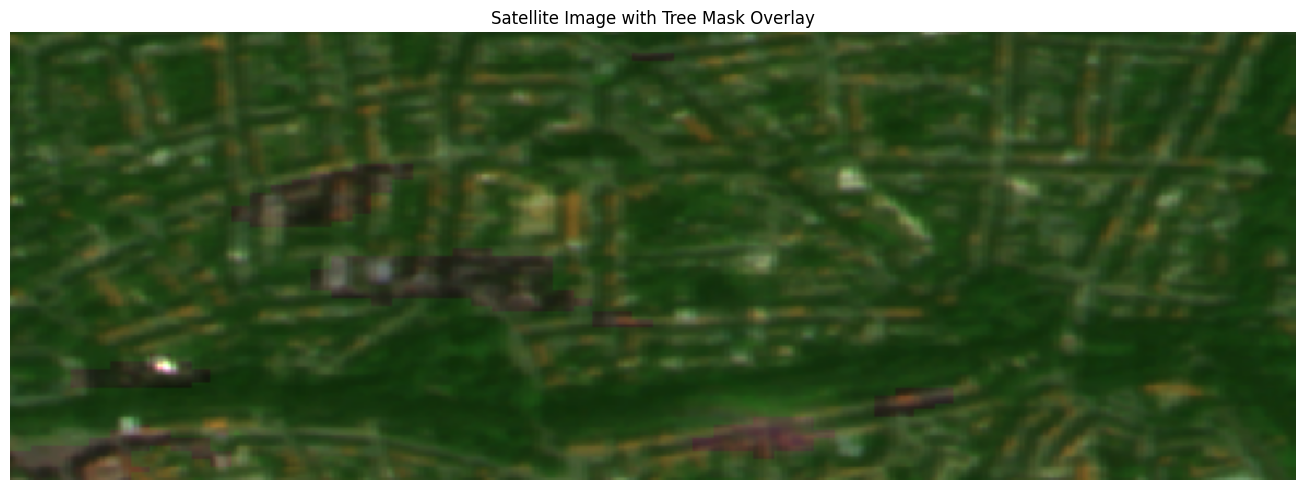

In [22]:
image_path = "/home/ubuntu/work/saved_data/geoai-project/geoai/storage/queries/0c1ca08a-1284-4718-9343-fa4aedd78698/input.tiff"
# image_path = "/home/ubuntu/work/saved_data/geoai-project/geoai/storage/queries/7b721135-8601-4b09-8c1f-2453b401804a/input.tiff"

target_dims = (64,64)
mask = predict_small_image(image_path, model, device, target_size=target_dims)
plot_prediction(image_path, mask)